In [2]:
import os
import glob
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from functools import reduce
from pyspark.sql import DataFrame

# 1. Khởi tạo Spark Session
spark = (SparkSession.builder
            .appName("TaxiDemandPrediction_HDFS")
            .config("spark.executor.memory", "2g") 
            .config("spark.driver.memory", "2g")   
            .config("spark.sql.execution.arrow.pyspark.enabled", "true") 
            .getOrCreate()
)

print("Đang nạp, chuẩn hóa và gộp dữ liệu từ từng file...")

# 2. Lấy danh sách tên file từ thư mục local để biết cần đọc gì trên HDFS
local_files = glob.glob("/workspace/data/raw/*.parquet")
file_names = [os.path.basename(f) for f in local_files]

df_list = []
for f_name in file_names:
    hdfs_path = f"/user/data/raw/{f_name}"
    try:
        # Đọc file với schema tự nhiên của chính nó (không ép khung)
        temp_df = spark.read.parquet(hdfs_path)
        
        # Chỉ trích xuất đúng 5 cột cần thiết và ép kiểu về chuẩn chung
        temp_df_clean = temp_df.select(
            F.col("PULocationID").cast("long").alias("PULocationID"),
            F.col("tpep_pickup_datetime").cast("timestamp").alias("tpep_pickup_datetime"),
            F.col("tpep_dropoff_datetime").cast("timestamp").alias("tpep_dropoff_datetime"),
            F.col("trip_distance").cast("double").alias("trip_distance"),
            F.col("total_amount").cast("double").alias("total_amount")
        )
        df_list.append(temp_df_clean)
    except Exception as e:
        print(f"[-] Bỏ qua file {f_name} do lỗi cấu trúc vật lý: {e}")

# 3. Gộp tất cả các DataFrame con thành một khối duy nhất
if df_list:
    df_taxi = reduce(DataFrame.unionAll, df_list)
    print(f"Tổng số bản ghi ban đầu: {df_taxi.count():,}") 
else:
    print("\nLỖI: Không đọc được file nào!")

ModuleNotFoundError: No module named 'pyspark'

In [4]:
# CELL 2 
import pyspark.sql.functions as F 
# 1. Loại bỏ các dòng thiếu thông tin quan trọng
df_clean = df_taxi.dropna(subset=["PULocationID", "tpep_pickup_datetime", "tpep_dropoff_datetime"])

# 2. Lọc bỏ các cuốc xe có khoảng cách hoặc giá tiền không hợp lý
df_clean = df_clean.filter(
    (F.col("trip_distance") > 0) &
    (F.col("total_amount") > 0)
)

# 3. Trích xuất đặc trưng thời gian từ cột tpep_pickup_datetime
df_clean = df_clean.withColumn("hour", F.hour("tpep_pickup_datetime")) \
                   .withColumn("day_of_week", F.dayofweek("tpep_pickup_datetime")) \
                   .withColumn("month", F.month("tpep_pickup_datetime")) \
                   .withColumn("year", F.year("tpep_pickup_datetime")) 
print(f"Tổng số bản ghi sau khi làm sạch: {df_clean.count():,}")

ModuleNotFoundError: No module named 'pyspark'

In [ ]:
# CELL 3 
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

# Lấy ngẫu nhiên 1% dữ liệu (fraction=0.01) để huấn luyện
df_sample = df_clean.sample(withReplacement=False, fraction=0.01, seed=42)

# Gom cột PULocationID thành vector
assembler = VectorAssembler(inputCols=["PULocationID"], outputCol="features", handleInvalid="skip")

# 1. BIẾN ĐỔI TẬP MẪU VÀ HUẤN LUYỆN
df_features_sample = assembler.transform(df_sample)

print("Đang chạy thuật toán K-Means trên tập dữ liệu mẫu...")
kmeans = KMeans().setK(5).setSeed(42).setFeaturesCol("features")
model_kmeans = kmeans.fit(df_features_sample)

# 2. ÁP DỤNG MÔ HÌNH CHO TOÀN BỘ DỮ LIỆU GỐC
print("Đang gán nhãn cụm cho toàn bộ hàng trăm triệu chuyến đi...")
df_features_all = assembler.transform(df_clean)
df_clustered = model_kmeans.transform(df_features_all)

print("Phân cụm K-Means thành công")

Đang chạy thuật toán K-Means trên tập dữ liệu mẫu...


26/04/03 11:05:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Đang gán nhãn cụm cho toàn bộ hàng trăm triệu chuyến đi...
Phân cụm K-Means thành công


In [4]:
# CELL 4
# Đếm số lượng chuyến đi theo từng Cụm (prediction),Năm, Tháng, Ngày trong tuần, và Giờ
demand_df = df_clustered.groupBy("prediction", "year", "month", "day_of_week", "hour") \
                        .agg(F.count("*").alias("busy_score"))
# Chuyển đổi DataFrame của Spark sang DataFrame của Pandas
print("Đang chuyển đổi dữ liệu tổng hợp sang Pandas...")
pdf = demand_df.toPandas()

print(f"Kích thước dữ liệu sau khi tổng hợp: {pdf.shape}")
pdf.head()

Đang chuyển đổi dữ liệu tổng hợp sang Pandas...


/usr/local/lib/python3.10/dist-packages/pyspark/sql/pandas/conversion.py:111: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  PyArrow >= 4.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


Kích thước dữ liệu sau khi tổng hợp: (60875, 6)


,prediction,year,month,day_of_week,hour,busy_score
0,0,2020,2,1,20,2246
1,3,2020,2,5,11,6197
2,0,2020,2,5,21,4602
3,0,2020,2,6,7,4233
4,3,2020,2,6,9,7366


In [5]:
import os
import glob

# Chỉ định thẳng đường dẫn tuyệt đối từ gốc /workspace vào tới thư mục
offline_dir = "/workspace/code/vanh/offline_packages"
print("Đường dẫn cài đặt Offline chính xác:", offline_dir)

# Kiểm tra xem thư mục có tồn tại và có file .whl không
if os.path.exists(offline_dir):
    whl_files = glob.glob(os.path.join(offline_dir, "*.whl"))
    print(f"Đã tìm thấy {len(whl_files)} file cài đặt (.whl) trong thư mục.\n")
    
    if len(whl_files) > 0:
        print("Bắt đầu cài đặt...")
        # Cài đặt bằng file:// để pip nhận diện đường dẫn ổ cứng
        !pip install --no-index --find-links=file://{offline_dir} scikit-learn xgboost
    else:
        print("LỖI: Thư mục tồn tại nhưng không có file .whl nào bên trong!")
else:
    print(f"LỖI: Vẫn không tìm thấy thư mục {offline_dir}!")


Đường dẫn cài đặt Offline chính xác: /workspace/code/vanh/offline_packages
Đã tìm thấy 6 file cài đặt (.whl) trong thư mục.

Bắt đầu cài đặt...
Looking in links: file:///workspace/code/vanh/offline_packages


In [1]:
# Lưu dữ liệu đã tổng hợp và phân cụm ra file CSV để dùng cho các mô hình khác
pdf.to_csv('/workspace/data/taxi_demand_features.csv', index=False)
print("Đã lưu dữ liệu features ra file CSV.")

NameError: name 'pdf' is not defined

In [7]:
# CELL 5
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Định nghĩa Đặc trưng (X) và Nhãn cần dự đoán (y)
X = pdf[['prediction', 'year', 'month', 'day_of_week', 'hour']]
y = pdf['busy_score']

# Chia tập dữ liệu (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Hàm in kết quả đánh giá (MSE, RMSE, R2)
def evaluate_model(model_name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Kết quả cho {model_name} ---")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}\n")

In [10]:
# CELL 6
import numpy as np

print("Đang huấn luyện Linear Regression...")
lr = LinearRegression()

lr_params = {'fit_intercept': [True, False]}

lr_grid = GridSearchCV(estimator=lr, param_grid=lr_params, cv=5, scoring='neg_mean_squared_error')
lr_grid.fit(X_train, y_train)

lr_best = lr_grid.best_estimator_
lr_preds = lr_best.predict(X_test)

evaluate_model("Linear Regression", y_test, lr_preds)

Đang huấn luyện Linear Regression...
--- Kết quả cho Linear Regression ---
MSE: 11346432.5669
RMSE: 3368.4466
R2 Score: 0.1746



In [11]:
# CELL 7
import numpy as np
print("Đang huấn luyện Random Forest Regressor...")
rf = RandomForestRegressor(random_state=42)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_random = RandomizedSearchCV(estimator=rf, param_distributions=rf_params, 
                               n_iter=5, cv=3, scoring='neg_mean_squared_error', 
                               random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)

rf_best = rf_random.best_estimator_
rf_preds = rf_best.predict(X_test)

evaluate_model("Random Forest Regressor", y_test, rf_preds)

Đang huấn luyện Random Forest Regressor...
--- Kết quả cho Random Forest Regressor ---
MSE: 304813.1878
RMSE: 552.0989
R2 Score: 0.9778



In [12]:
# CELL 8 
import numpy as np
print("Đang huấn luyện XGBoost Regressor...")
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

xgb_random = RandomizedSearchCV(estimator=xg_reg, param_distributions=xgb_params, 
                                n_iter=5, cv=3, scoring='neg_mean_squared_error', 
                                random_state=42, n_jobs=-1)
xgb_random.fit(X_train, y_train)

xgb_best = xgb_random.best_estimator_
xgb_preds = xgb_best.predict(X_test)

evaluate_model("XGBoost Regressor", y_test, xgb_preds)

Đang huấn luyện XGBoost Regressor...


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GP

--- Kết quả cho XGBoost Regressor ---
MSE: 198764.2031
RMSE: 445.8298
R2 Score: 0.9855



--- Độ quan trọng của các biến (XGBoost) ---


/tmp/ipykernel_9238/1939286042.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


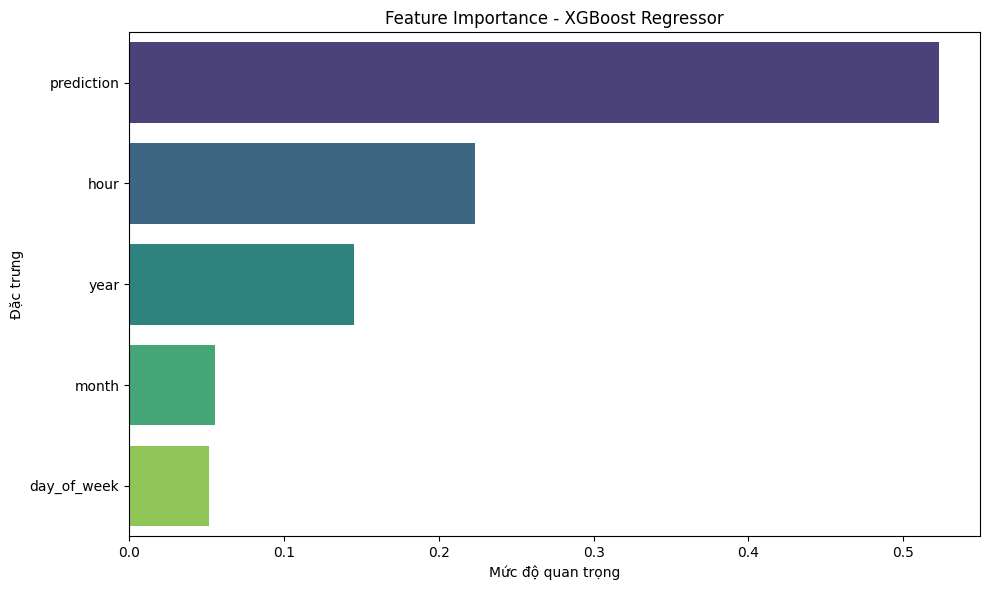

In [15]:
# CELL 9 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
 
print("--- Độ quan trọng của các biến (XGBoost) ---")
# Lấy danh sách độ quan trọng từ mô hình XGBoost tốt nhất
importances = xgb_best.feature_importances_
feature_names = X.columns

# Tạo DataFrame để vẽ biểu đồ
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Trực quan hóa bằng Barplot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('Feature Importance - XGBoost Regressor')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

In [16]:
# CELL 10
import joblib

# Giả sử XGBoost là mô hình cho kết quả R2 cao nhất 
best_model = xgb_best
model_filename = 'taxi_demand_xgboost_model.pkl'

# Lưu mô hình xuống ổ cứng
joblib.dump(best_model, model_filename)
print(f"Đã lưu mô hình tốt nhất thành công tại: {model_filename}")



Đã lưu mô hình tốt nhất thành công tại: taxi_demand_xgboost_model.pkl
